Question 7 Part A

In [ ]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Data without inhibitor
s = np.array([0.40, 0.52, 0.67, 0.86, 1.11, 1.44, 1.86, 2.40, 3.10, 4.00])
v_no = np.array([8.22, 10.19, 12.40, 14.87, 17.67, 20.74, 23.90, 27.08, 30.20, 33.16]) * 1e-3

# Compute inverses for Lineweaver-Burk
inv_s = 1 / s
inv_v_no = 1 / v_no

# Linear regression
result_no = linregress(inv_s, inv_v_no)
slope_no = result_no.slope
intercept_no = result_no.intercept
r_squared = result_no.rvalue**2

# Calculate parameters
V_max = 1 / intercept_no  # mmol/(L min)
K_M = slope_no * V_max    # mmol/L

# Output results
print(f"V_max: {V_max:.5f} mmol/(L min)")
print(f"K_M: {K_M:.3f} mmol/L")
print(f"R_squared: {r_squared:.4f}")

V_max: 0.05004 mmol/(L min)
K_M: 2.034 mmol/L
R_squared: 1.0000


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

# raw data
CA = np.array([0.40, 0.52, 0.67, 0.86, 1.11, 1.44, 1.86, 2.40, 3.10, 4.00])  # mmol/L
r_no = np.array([8.22, 10.19, 12.40, 14.87, 17.67, 20.74, 23.90, 27.08, 30.20, 33.16]) * 1e-3  # mmol/L·min

# transforms for Lineweaver–Burk
inv_CA = 1.0 / CA
inv_r_no = 1.0 / r_no

table_no = pd.DataFrame({
    "C_A (mmol/L)": CA,
    "-r_A (mmol/L/min)": r_no,
    "1/C_A (L/mmol)": inv_CA,
    "1/(-r_A) (L·min/mmol)": inv_r_no
})
table_no


,C_A (mmol/L),-r_A (mmol/L/min),1/C_A (L/mmol),1/(-r_A) (L·min/mmol)
0,0.40,0.00822,2.500000,121.654501
1,0.52,0.01019,1.923077,98.135427
2,0.67,0.01240,1.492537,80.645161
3,0.86,0.01487,1.162791,67.249496
4,1.11,0.01767,0.900901,56.593096
5,1.44,0.02074,0.694444,48.216008
6,1.86,0.02390,0.537634,41.841004
7,2.40,0.02708,0.416667,36.927622
8,3.10,0.03020,0.322581,33.112583
9,4.00,0.03316,0.250000,30.156815


In [ ]:
res_no = linregress(inv_CA, inv_r_no)
m_no = res_no.slope      # slope = K_M / Vmax
b_no = res_no.intercept  # intercept = 1 / Vmax

print("slope_no =", m_no)
print("intercept_no =", b_no)
print("R^2 =", res_no.rvalue**2)


slope_no = 40.65386625427378
intercept_no = 19.98365836132251
R^2 = 0.9999996394291418


In [ ]:
Vmax = 1.0 / b_no                      # mmol/(L·min)
Km = m_no * Vmax                       # mmol/L

print("Vmax =", Vmax, "mmol/(L·min)")
print("Km =", Km, "mmol/L")


Vmax = 0.05004088750513549 mmol/(L·min)
Km = 2.034355547878938 mmol/L


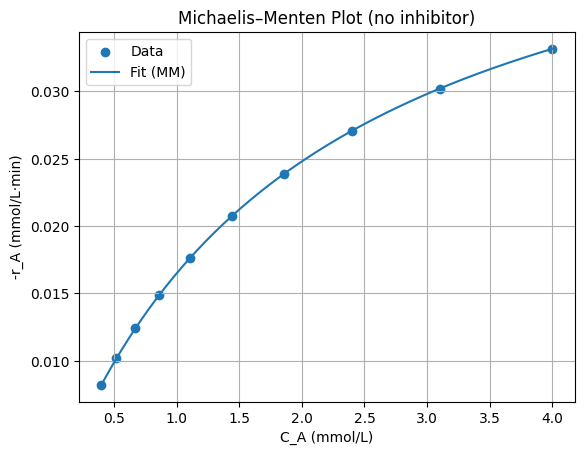

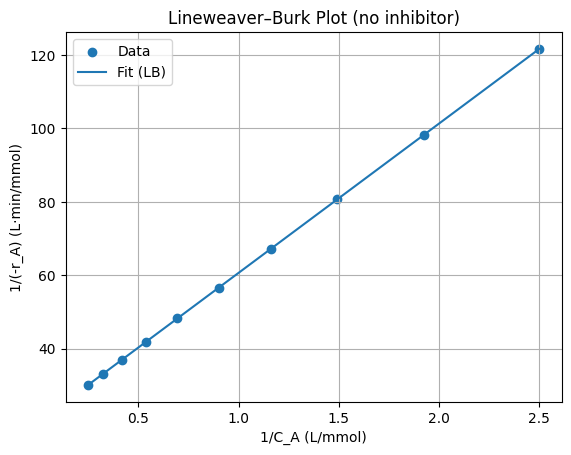

In [ ]:
import matplotlib.pyplot as plt

# 1. Michaelis–Menten plot
CA_fine = np.linspace(min(CA), max(CA), 200)
v_fit = Vmax * CA_fine / (Km + CA_fine)

plt.figure()
plt.scatter(CA, r_no, label="Data")
plt.plot(CA_fine, v_fit, label="Fit (MM)")
plt.xlabel("C_A (mmol/L)")
plt.ylabel("-r_A (mmol/L·min)")
plt.title("Michaelis–Menten Plot (no inhibitor)")
plt.legend()
plt.grid(True)

# 2. Lineweaver–Burk plot
y_fit_no = m_no * inv_CA + b_no

plt.figure()
plt.scatter(inv_CA, inv_r_no, label="Data")
plt.plot(inv_CA, y_fit_no, label="Fit (LB)")
plt.xlabel("1/C_A (L/mmol)")
plt.ylabel("1/(-r_A) (L·min/mmol)")
plt.title("Lineweaver–Burk Plot (no inhibitor)")
plt.legend()
plt.grid(True)


Question 7 Part B

In [ ]:
from mpmath import findroot, log  # Import log from mpmath

Km_val = Km        # from part a
Vmax_val = Vmax
CA0 = 1.0
t = 10.0

def g(CA):
    return Km_val * log(CA0 / CA) + (CA0 - CA) - Vmax_val * t # Use mpmath.log

CA_guess = 0.8  # reasonable starting guess
CA_10 = findroot(g, CA_guess)  # float value

print("C_A(10 min) =", CA_10, "mmol/L")
X_10 = (CA0 - CA_10) / CA0
print("Conversion at 10 min =", X_10)

C_A(10 min) = 0.844182835680655 mmol/L
Conversion at 10 min = 0.155817164319345


Question 7 Part c

In [ ]:
r_inh = np.array([2.988, 3.80, 4.81, 6.01, 7.49, 9.30, 11.40, 13.80, 16.49, 19.41]) * 1e-3
inv_r_inh = 1.0 / r_inh

res_inh = linregress(inv_CA, inv_r_inh)  # same 1/C_A
m_inh = res_inh.slope
b_inh = res_inh.intercept

print("slope_inh =", m_inh)
print("intercept_inh =", b_inh)
print("R^2 (inh) =", res_inh.rvalue**2)

Vmax_inh = 1.0 / b_inh
Km_inh = m_inh * Vmax_inh

print("Vmax_inh =", Vmax_inh, "mmol/(L·min)")
print("Km_inh =", Km_inh, "mmol/L")


slope_inh = 126.0396764909113
intercept_inh = 19.9819063369535
R^2 (inh) = 0.9999892611768408
Vmax_inh = 0.05004527511725205 mmol/(L·min)
Km_inh = 6.3076902856771015 mmol/L


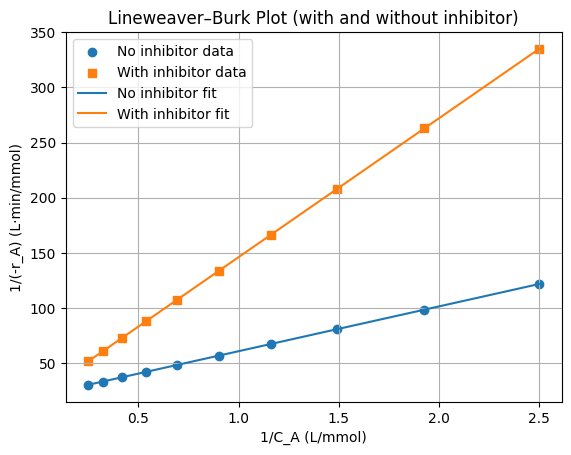

In [ ]:
y_fit_no = m_no * inv_CA + b_no
y_fit_inh = m_inh * inv_CA + b_inh

plt.figure()
plt.scatter(inv_CA, inv_r_no, label="No inhibitor data")
plt.scatter(inv_CA, inv_r_inh, label="With inhibitor data", marker="s")

plt.plot(inv_CA, y_fit_no, label="No inhibitor fit")
plt.plot(inv_CA, y_fit_inh, label="With inhibitor fit")

plt.xlabel("1/C_A (L/mmol)")
plt.ylabel("1/(-r_A) (L·min/mmol)")
plt.title("Lineweaver–Burk Plot (with and without inhibitor)")
plt.legend()
plt.grid(True)


Question 7 Part D

In [ ]:
I_conc = 0.105  # mmol/L

KI = I_conc / (m_inh / m_no - 1.0)
print("K_I =", KI, "mmol/L")


K_I = 0.04999256837721197 mmol/L
